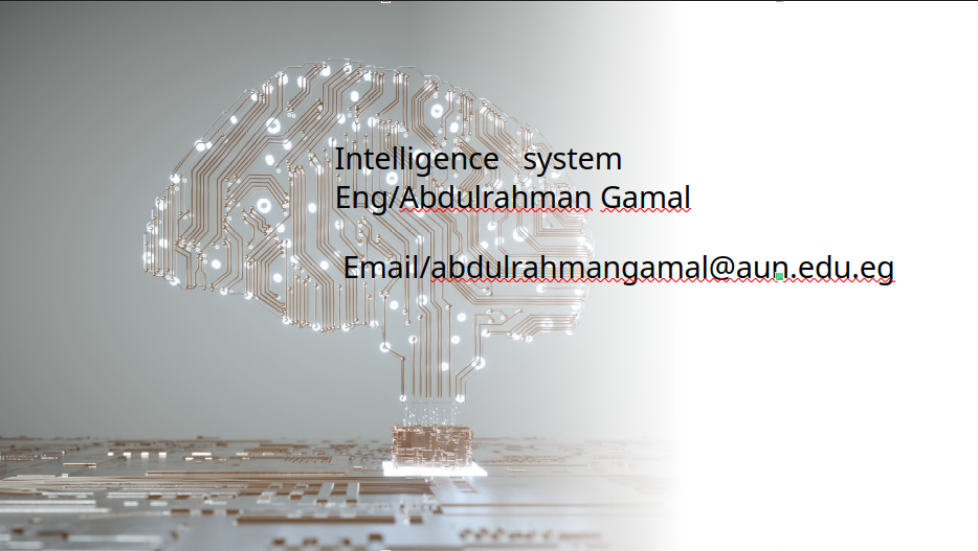

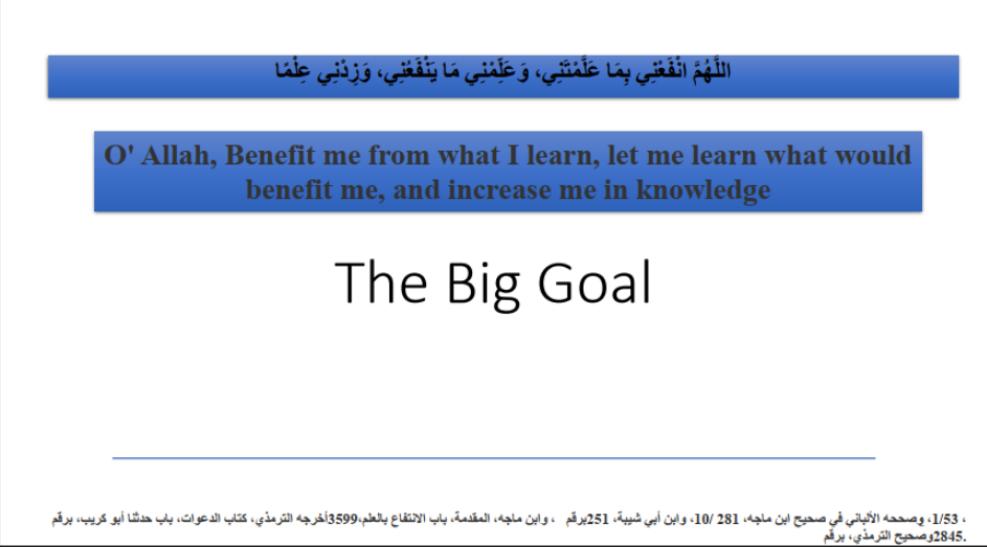

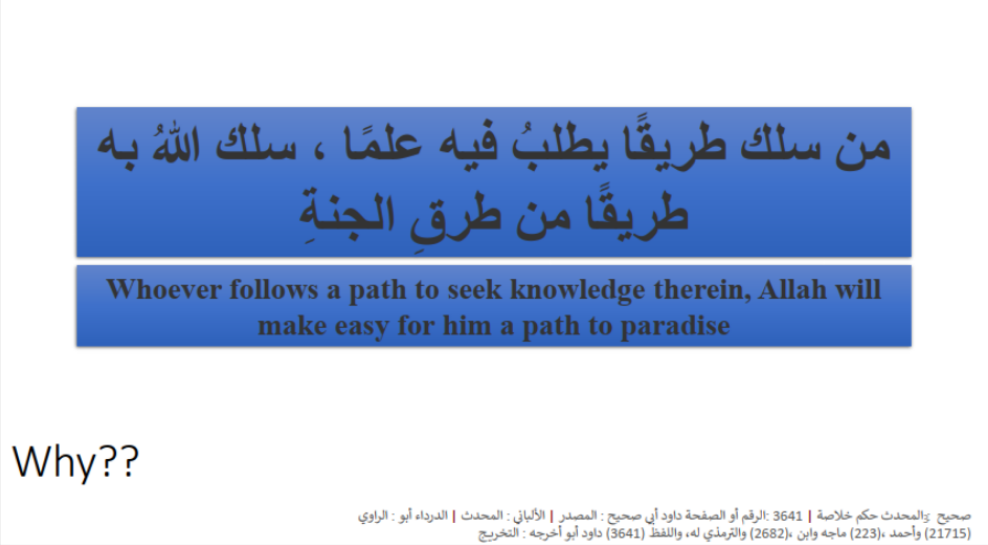

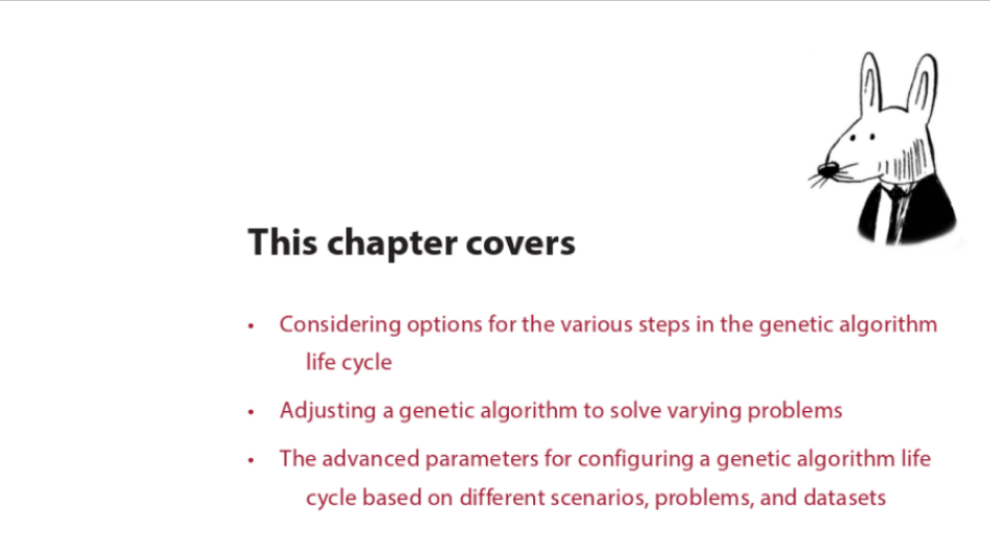

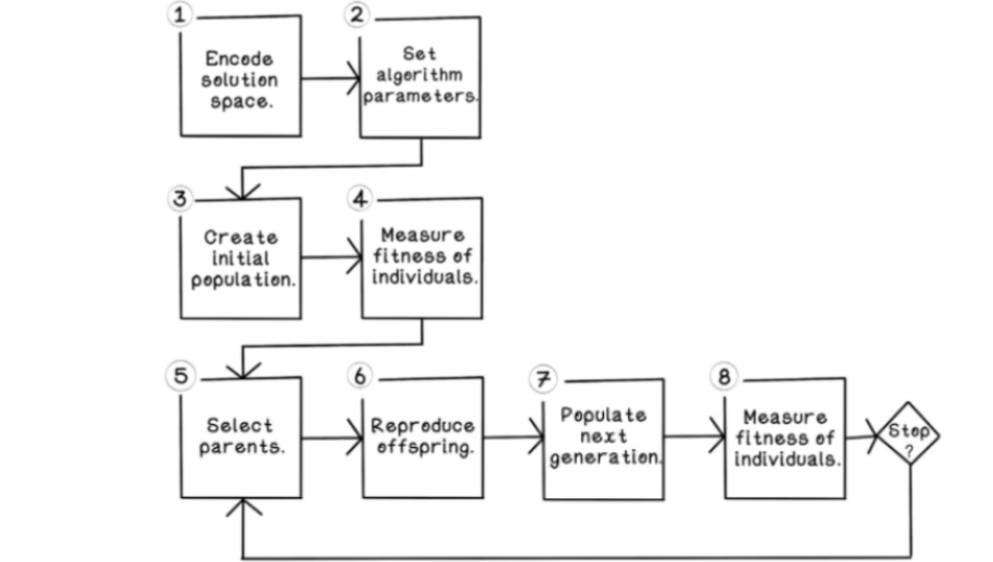

# 1-Alternative selection strategies

- 1.1-Rank selection: Even the playing field
- 1.2-Tournament selection: Let them fight
- 1.3-Elitism selection: Choose only the best


### 1.1-Rank selection: Even the playing field


Why need this ?

One ` problem ` with roulette-wheel selection is the `vast differences `in the magnitude of 
fitness between chromosomes.

This heavily `biases` the selection toward choosing indi-
viduals with `high fitness` scores or giving `poor-performing` individuals a larger chance of 
selection than desired 

This problem affects the diversity of the population. More `diversity means`   
more exploration of the search space, but it can also make finding optimal 
solutions take too `many generations`



How it work ?

`Rank selection aims `to solve this problem by ranking individuals based on their fit-
ness and then using each individual’s rank as the value for calculating the size of its slice 
on the wheel


Need example ?




![Screenshot from 2026-03-08 17-05-19.png](<attachment:Screenshot from 2026-03-08 17-05-19.png>)       

In Rank Selection: The "best" individual gets 16 points, the next gets 15, and the worst gets 1 point.    
 The difference between the best and worst is only a factor of 16:1.            

In Roulette-wheel (Fitness-based): If individual A has a fitness of 1000 and individual P has a fitness of 1,         
the difference is      1000:1.     
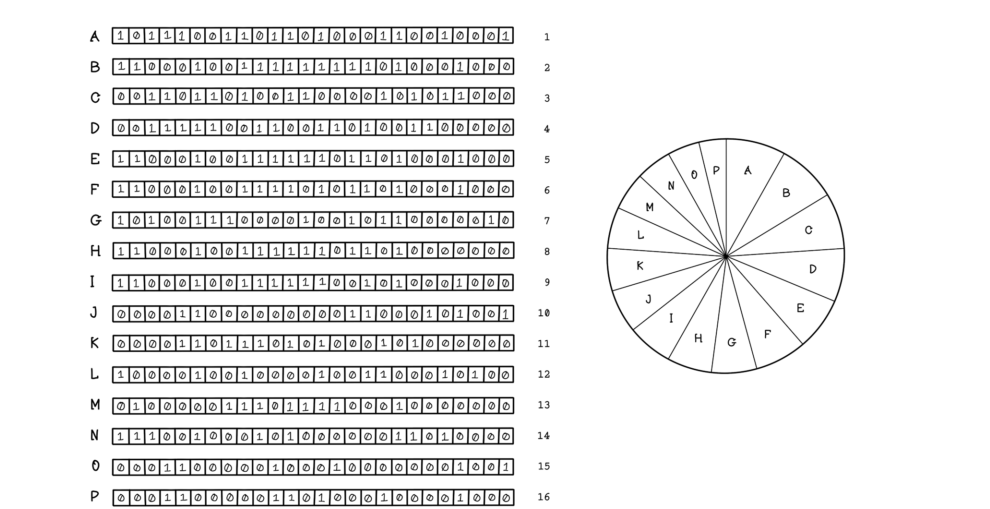

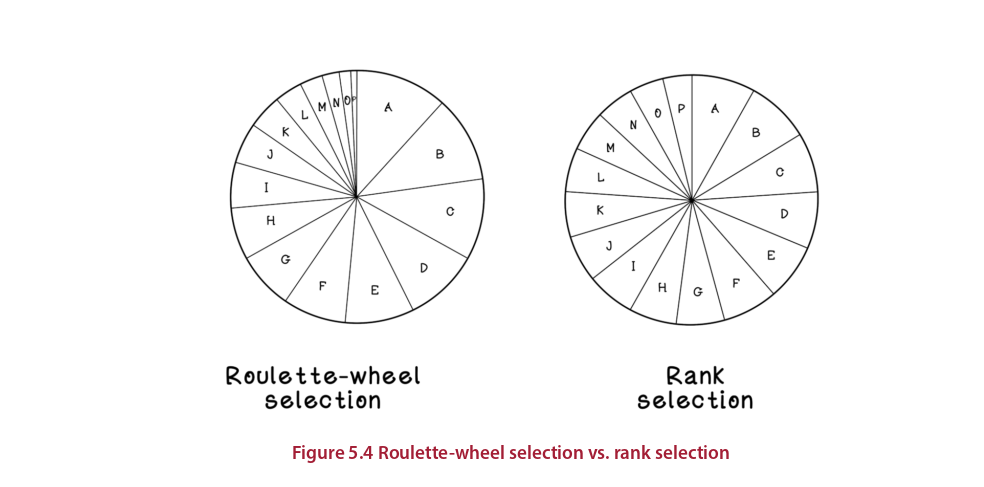

### need code ?

convert  selection process to Rank Selection in last example in last section 

In [196]:
import random
INDIVIDUAL_CHROMOSOME_INDEX = 0
INDIVIDUAL_FITNESS_INDEX = 1
INDIVIDUAL_PROBABILITY_INDEX = 2
# New helper to set probabilities based on Rank instead of Fitness
def set_rank_probabilities(population):
    # 1. Sort population by fitness (Worst at the start, Best at the end)
    # This ensures the 'worst' gets Rank 1 and 'best' gets Rank N
    population.sort(key=lambda ind: ind[INDIVIDUAL_FITNESS_INDEX])
    
    # 2. Calculate the sum of all ranks (1 + 2 + 3 ... + N)
    # Formula for sum of N numbers: (N * (N + 1)) / 2
    n = len(population)
    rank_sum = (n * (n + 1)) / 2
    
    # 3. Assign probability based on the rank (index + 1)
    for index, individual in enumerate(population):
        rank = index + 1
        individual[INDIVIDUAL_PROBABILITY_INDEX] = rank / rank_sum



def rank_selection(population, number_of_selections):
    # Use the new ranking logic
    set_rank_probabilities(population)
    
    slices = []
    total = 0
    
    # Create the wheel slices based on the new rank probabilities
    for r in range(0, len(population)):
        individual = population[r]
        slices.append([r, total, total + individual[INDIVIDUAL_PROBABILITY_INDEX]])
        total += individual[INDIVIDUAL_PROBABILITY_INDEX]

    chosen_ones = []
    for r in range(number_of_selections):
        spin = random.random()
        # Find which slice the 'spin' landed in
        result = [s[0] for s in slices if s[1] < spin <= s[2]]
        
        # In case of rounding errors at 1.0, pick the last individual
        if not result:
            chosen_ones.append(population[-1])
        else:
            chosen_ones.append(population[result[0]])
            
    return chosen_ones


#What to update in your run_ga() function:
## Inside your run_ga() function, change this line:
#the_chosen = rank_selection(global_population, 100)

### 1.2-Tournament selection: Let them fight


How it work ?

Tournament selection plays chromosomes against one other.   

 Tournament selection randomly chooses a set number of individuals from the population and places them in a 
group. This process is performed for a predetermined number of groups.   
The individual with the highest fitness score in each respective group is selected.   


what is config ? 


- The `larger the group size `, the `less diverse` it is, because only one individual from each group is selected.    
- As with rank selection, the actual fitness score of each individual is not the key factor in selecting 
individuals globally.


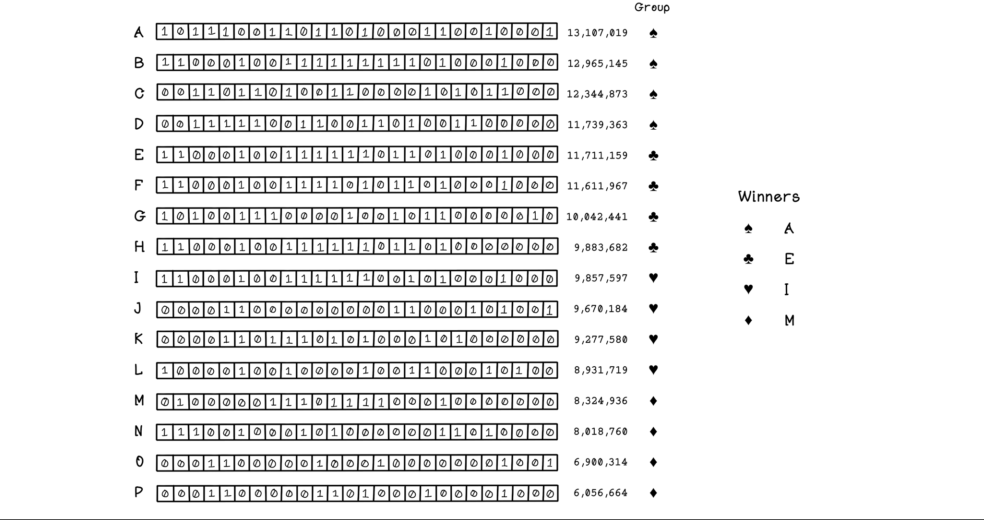

need code? 

In [197]:
def tournament_selection(population, number_of_selections, tournament_size=3):
    """
    population: The current list of individuals
    number_of_selections: How many parents we need to pick for reproduction
    tournament_size: How many individuals 'fight' in each round (usually 3 or 5)
    """
    chosen_ones = []

    for _ in range(number_of_selections):
        # 1. Randomly pick 'tournament_size' individuals from the population
        # weights/probabilities are NOT used here - it's purely random entry
        aspirants = random.sample(population, tournament_size)
        
        # 2. The one with the highest fitness wins the tournament
        # We use the INDIVIDUAL_FITNESS_INDEX (index 1) to determine the winner
        winner = max(aspirants, key=lambda ind: ind[INDIVIDUAL_FITNESS_INDEX])
        
        chosen_ones.append(winner)
        
    return chosen_ones
"""

How to update your run_ga() function (Cell 9)
 Inside your run_ga() function:
 Higher tournament_size (e.g. 10) means more pressure (only the very best win)
 Lower tournament_size (e.g. 2) means more diversity (weaker ones have a chance)
the_chosen = tournament_selection(global_population, 100, tournament_size=5)

"""

'\n\nHow to update your run_ga() function (Cell 9)\n Inside your run_ga() function:\n Higher tournament_size (e.g. 10) means more pressure (only the very best win)\n Lower tournament_size (e.g. 2) means more diversity (weaker ones have a chance)\nthe_chosen = tournament_selection(global_population, 100, tournament_size=5)\n\n'

### Comparison Summary

Use Rank Selection when:        
` Small Populations ` : When your population size is small (under 100), sorting is fast, and you want very precise control over  probabilities.         

` Stagnant Fitness`: When many individuals have almost the same fitness score, ranking them 1, 2, 3...  
helps create clear distinctions for selection.    

Use Tournament Selection when:     
` Large Populations:`  It is the industry standard for `large-scale Genetic `Algorithms because it is much faster (no sorting).

You want to tune "` Selection Pressure" `: If your GA is finding a solution too slowly, you just turn up the tournament size. If it's    converging too fast on a bad solution, you turn it down.     

### Summary
The Core Difference: Global vs. Local  
The easiest way to understand the difference is how they look at the population:  

`Rank Selection` looks at the `whole population`. It has to line everyone up from worst to best, assign them a rank, and spin a giant   weighted wheel.   

`Tournament Selection` looks at a `small group`. It blindly grabs a few individuals from the crowd, tosses them in a ring, and the best one of that specific group wins. It doesn't care about the rest of the population at that moment.  

# 2- Replacement Strategy  or Survivor Selection


2.1 Mu + Lambda ($\mu + \lambda$) / Truncation (Your Original Method)     
2.2 Generational Replacement (The Industry Standard)     
2.3 Steady-State Replacement    

### 2.2 Mu + Lambda ($\mu + \lambda$) / Truncation ( last section code use it  Method)   

How it works:               
You take all of your current parents ($\mu$) and all of your newly generated children ($\lambda$) and throw them into one giant pool together. You rank everyone by their fitness score, keep the top half, and ruthlessly delete the rest.          

Pros:       
 It is incredibly fast at finding a "pretty good" high score because bad genes are instantly wiped out.       

Cons:         
It destroys genetic diversity rapidly. If a child has a "weird" but potentially useful gene, it usually dies immediately because its overall score isn't high enough yet to beat the perfected parents. This causes your algorithm to get permanently stuck on a good (but not perfect) solution.  

In [198]:
INITIAL_POPULATION_SIZE = 1000
# Method 1: Mu + Lambda (Your original style)
def merge_mu_plus_lambda(population, children):
    combined_pool = population + children
    combined_pool.sort(key=lambda ind: ind[INDIVIDUAL_FITNESS_INDEX], reverse=True)
    return combined_pool[:INITIAL_POPULATION_SIZE]

"""
# CHANGE 1 in run_Ga : Select 100 parents
the_chosen = roulette_wheel_selection(global_population, 100)

the_children = reproduce_children(the_chosen)
the_children = mutate_children(the_children, MUTATION_RATE)
calculate_population_fitness(the_children, KNAPSACK_WEIGHT_CAPACITY)

# CHANGE 2 in run_Ga : Call the Mu + Lambda merge
global_population = merge_mu_plus_lambda(global_population, the_children)

"""

'\n# CHANGE 1 in run_Ga : Select 100 parents\nthe_chosen = roulette_wheel_selection(global_population, 100)\n\nthe_children = reproduce_children(the_chosen)\nthe_children = mutate_children(the_children, MUTATION_RATE)\ncalculate_population_fitness(the_children, KNAPSACK_WEIGHT_CAPACITY)\n\n# CHANGE 2 in run_Ga : Call the Mu + Lambda merge\nglobal_population = merge_mu_plus_lambda(global_population, the_children)\n\n'

### 2.2. Generational Replacement with Elitism (The VIP Pass)     

Generational Replacement with Elitism (The VIP Pass)         
This is the industry standard for most modern Genetic Algorithms, and it is much more balanced.      

How it works:         
You assume that the parents are going to die off entirely to make room for the children. However, before the parents disappear, you grant a "VIP Pass" to the absolute top 1% or 2% of the parents (the Elites). Those few elites walk straight into the next generation safely. The remaining 98% of the next generation is filled entirely by newly bred, mutated children.     


Pros:       
It guarantees your high score never accidentally drops, while maintaining massive genetic diversity because the new children only compete against each other, not against the super-parents.     

Cons:   

 It can take slightly more generations (more time) to reach the final answer compared to $\mu + \lambda$, but the final answer is usually better.

In [199]:
def merge_generational_elitism(population, children, elite_count=10):
    # 1. Sort the parents from best to worst to find the VIPs
    population.sort(key=lambda ind: ind[INDIVIDUAL_FITNESS_INDEX], reverse=True)
    
    # 2. Extract the absolute best parents (The Elites)
    elites = population[:elite_count]
    
    # 3. Sort the children so we keep only the best children to fill the remaining spots
    children.sort(key=lambda ind: ind[INDIVIDUAL_FITNESS_INDEX], reverse=True)
    spots_left = INITIAL_POPULATION_SIZE - elite_count
    best_children = children[:spots_left]
    
    # Combine the untouched Elites with the new Children
    return elites + best_children


    """
    
    # CHANGE 1 in run_Ga : Select 990 parents (1000 total size - 10 elites)
        the_chosen = roulette_wheel_selection(global_population, INITIAL_POPULATION_SIZE - 10)
        
        the_children = reproduce_children(the_chosen)
        the_children = mutate_children(the_children, MUTATION_RATE)
        calculate_population_fitness(the_children, KNAPSACK_WEIGHT_CAPACITY)
        
        # CHANGE 2in run_Ga : Call the Elitism merge
        global_population = merge_generational_elitism(global_population, the_children, elite_count=10)
    """

### 2.3. Steady-State Selection (The Revolving Door)

How it works:         
Instead of replacing 1000 individuals all at once, you only select 2 parents (using Tournament or Rank selection) and create 2 new children.           
Then, you look at your main population, find the 2 absolute worst performing individuals, and delete them.     
You put the 2 brand-new children into those empty spots. The other 998 individuals in the population are completely untouched and just keep living.  
` only make one crossover ` 

Pros:     
It is extremely `protective of your good solutions`. The top 90% of your population is never at risk of dying, so you naturally maintain a very strong, stable pool of "veterans" while constantly testing out new "rookies" at the bottom.

Cons:        
It can be `very slow`. Because you are only replacing 1 or 2 individuals at a time instead of processing hundreds in bulk, it takes a lot longer for a new, great genetic trait to spread through the entire population.

In [200]:
def merge_steady_state(population, children):
    # 1. Sort the main population from best to worst
    population.sort(key=lambda ind: ind[INDIVIDUAL_FITNESS_INDEX], reverse=True)
    
    # 2. Figure out how many children we made
    num_children = len(children)
    
    # 3. Slice the population to remove the absolute worst ones at the very bottom
    # (If we made 2 children, we delete the 2 worst parents)
    surviving_parents = population[:-num_children]
    
    # Combine the surviving veterans with the brand new rookies
    return surviving_parents + children

    """ 
    # CHANGE 1 in run_Ga : Select exactly 2 parents
        the_chosen = roulette_wheel_selection(global_population, 2)
        
        the_children = reproduce_children(the_chosen)
        the_children = mutate_children(the_children, MUTATION_RATE)
        calculate_population_fitness(the_children, KNAPSACK_WEIGHT_CAPACITY)
        
        # CHANGE 2 in run_Ga : Call the Steady-State merge
        global_population = merge_steady_state(global_population, the_children)
    """

# 3-Real-value encoding:  



Consider that the Knapsack Problem has changed slightly. The problem remains choos-
ing the most valuable items to fill the weight capacity of the knapsack. But the choice 
involves more than one unit of each item. As shown in table 5.1, the weights and values 
remain the same as the original dataset, but a quantity of each item is included


Real-value encoding `represents `a gene in terms of numeric values, strings, or symbols, 
and expresses potential solutions in the natural state respective to the problem


` new representation mean  new encode ,crossover , mutation `

1- Arithmetic crossover  
2- boundary mutation   
3- Arithmetic mutation   


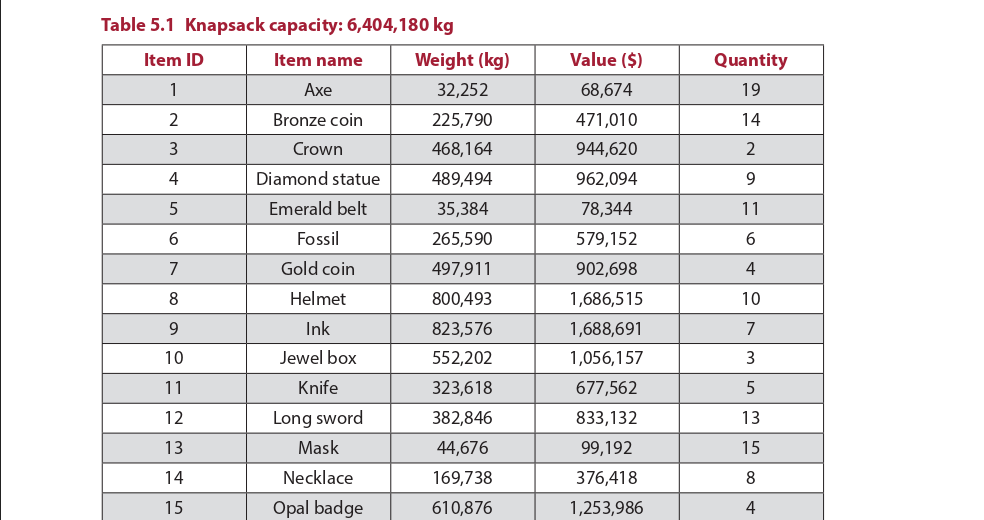
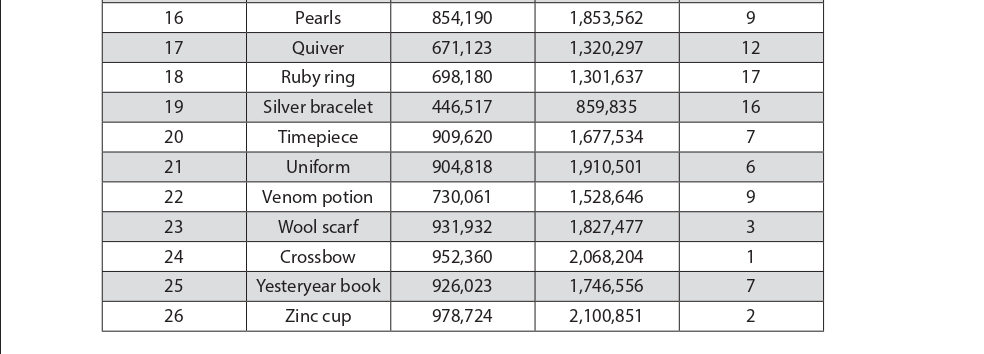

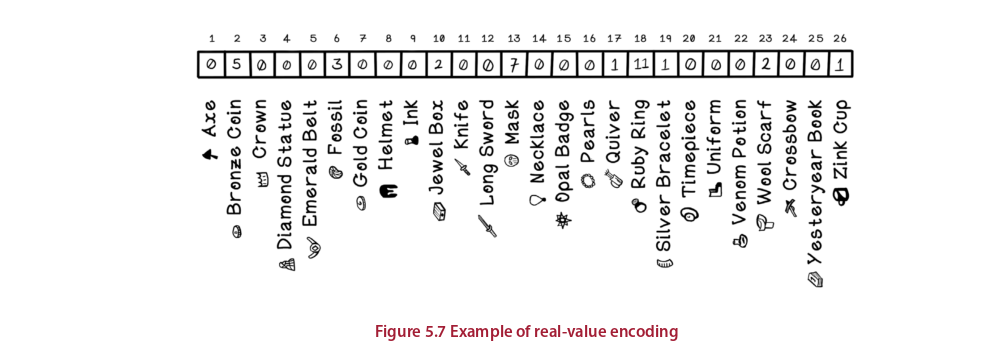

Because the encoding scheme has been changed, `new crossover `and `mutation `options 
become available. The crossover approaches discussed for binary encoding are still valid 
options to real-value encoding, `but mutation should be approached differently`.


In [201]:
KNAPSACK_ITEM_NAME_INDEX = 0
KNAPSACK_ITEM_WEIGHT_INDEX = 1
KNAPSACK_ITEM_VALUE_INDEX = 2
KNAPSACK_ITEM_QUANTITY_INDEX = 3 # NEW!

INDIVIDUAL_CHROMOSOME_INDEX = 0
INDIVIDUAL_FITNESS_INDEX = 1

In [202]:
knapsack_items = [
    ['Axe', 32252, 68674, 3],
    ['Bronze coin', 225790, 471010, 3],
    ['Crown', 468164, 944620, 3],
    ['Diamond statue', 489494, 962094, 3],
    ['Emerald belt', 35384, 78344, 3],
    ['Fossil', 265590, 579152, 3],
    ['Gold coin', 497911, 902698, 3],
    ['Helmet', 800493, 1686515, 3],
    ['Ink', 823576, 1688691, 3],
    ['Jewel box', 552202, 1056157, 3],
    ['Knife', 323618, 677562, 3],
    ['Long sword', 382846, 833132, 3],
    ['Mask', 44676, 99192, 3],
    ['Necklace', 169738, 376418, 3],
    ['Opal badge', 610876, 1253986, 3],
    ['Pearls', 854190, 1853562, 3],
    ['Quiver', 671123, 1320297, 3],
    ['Ruby ring', 698180, 1301637, 3],
    ['Silver bracelet', 446517, 859835, 3],
    ['Timepiece', 909620, 1677534, 3],
    ['Uniform', 904818, 1910501, 3],
    ['Venom potion', 730061, 1528646, 3],
    ['Wool scarf', 931932, 1827477, 3],
    ['Cross bow', 952360, 2068204, 3],
    ['Yesteryear book', 926023, 1746556, 3],
    ['Zinc cup', 978724, 2100851, 3] 
]

In [203]:
def generate_initial_population(population_size):
    population = []
    for _ in range(population_size):
        # Pick a random integer between 0 and the max available quantity for every item
        chromosome = []
        for i in range(len(knapsack_items)):
            max_qty = knapsack_items[i][KNAPSACK_ITEM_QUANTITY_INDEX]  # from dataset knapsack_items
            chromosome.append(random.randint(0, max_qty))
            
        population.append([chromosome, 0])
    return population

This code like  old section

In [204]:

def calculate_population_fitness(population, maximum_weight):
    best_fitness = 0
    
    for individual in population:
        # 1. Get the score from your individual calculation
        fitness = calculate_individual_fitness(individual[INDIVIDUAL_CHROMOSOME_INDEX], maximum_weight)
        
        # 2. Assign the score directly to their placeholder slot
        # DO NOT use .remove() or .pop() to delete them if they fail!
        individual[INDIVIDUAL_FITNESS_INDEX] = fitness
        
        # 3. Keep track of the highest valid score
        if fitness > best_fitness:
            best_fitness = fitness
            
    return best_fitness

# Instead of checking if gene == '1', we now look at the integer and multiply the weight and value by that number.

def calculate_individual_fitness(individual, maximum_weight):
    total_individual_weight = 0
    total_individual_value = 0
    
    # 2. Loop over the 26 genes INSIDE the chromosome
    for gene_index in range(len(individual)):
        # Now this will correctly grab a single integer (e.g., 3 or 5)
        quantity_chosen = individual[gene_index] 
        
        if quantity_chosen > 0:
            # Multiply the weight and value by how many we decided to take
            total_individual_weight += (knapsack_items[gene_index][KNAPSACK_ITEM_WEIGHT_INDEX] * quantity_chosen)
            total_individual_value += (knapsack_items[gene_index][KNAPSACK_ITEM_VALUE_INDEX] * quantity_chosen)
            
    # 3. Apply the weight limit penalty
    if total_individual_weight > maximum_weight:
        return -1  # -1 means this knapsack is too heavy to survive
        
    return total_individual_value

In [205]:
import random

def select_parents(population, num_parents_needed, tournament_size=3):
    """
    Selects parents by picking a few random individuals and choosing the best one.
    """
    selected_parents = []
    
    for _ in range(num_parents_needed):
        # 1. Pick a few random individuals from the population to compete
        tournament_competitors = random.sample(population, tournament_size)
        
        # 2. The winner is the one with the highest fitness score
        winner = max(tournament_competitors, key=lambda ind: ind[INDIVIDUAL_FITNESS_INDEX])
        
        # 3. Add the winner to our chosen parent pool
        selected_parents.append(winner)
        
    return selected_parents

## 3.1-Arithmetic crossover: Reproduce with math


The crossover approaches discussed for binary encoding are still valid options to real-value encoding,


Arithmetic crossover involves an arithmetic operation to be computed by using each parent as variables in the expression.      
The result of applying an arithmetic operation using both parents is the new offspring    




The Formula:   
You pick a random percentage (called $\alpha$) between $0$ and $1$.   
$Child_1 = (\alpha \times Parent_1) + ((1 - \alpha) \times Parent_2)$   

Example in your Knapsack:      

Let's say Parent 1 takes 10 Axes, and Parent 2 takes 2 Axes.    
If the random percentage is $0.5$ (a perfect 50/50 average):       
$ Child = (0.5 \times 10) + (0.5 \times 2) = 5 + 1 = 6      
              
$ The child will take 6 Axes.          

In [206]:
def arithmetic_crossover(selected_parents):
    """
    Takes a list of selected parents and mathematically blends their integer genes.
    """
    children = []
    
    # Step through the chosen parents in pairs (2 at a time)
    for i in range(0, len(selected_parents), 2):
        
        # Get the lists of integers (the chromosomes)
        p1_chromosome = selected_parents[i][INDIVIDUAL_CHROMOSOME_INDEX]
        
        # Protect against an odd number of parents by looping back to index 0
        p2_index = i + 1 if i + 1 < len(selected_parents) else 0 
        p2_chromosome = selected_parents[p2_index][INDIVIDUAL_CHROMOSOME_INDEX]
        
        child1_chromosome = []
        child2_chromosome = []
        
        # Pick a random blending percentage between 0.0 and 1.0
        alpha = random.random()
        
        # Blend each gene together using the arithmetic formula
        for gene1, gene2 in zip(p1_chromosome, p2_chromosome):
            
            c1_math = (alpha * gene1) + ((1 - alpha) * gene2)
            c2_math = ((1 - alpha) * gene1) + (alpha * gene2)
            
            # Convert back to integers so we don't have partial items!
            child1_chromosome.append(int(c1_math))
            child2_chromosome.append(int(c2_math))
            
        # Add the new offspring to the final list
        children.append([child1_chromosome, 0, 0])
        children.append([child2_chromosome, 0, 0])
        
    return children

` Arithmetic crossover is applicable to binary encoding and real-value encoding (figure 5.8)    `   


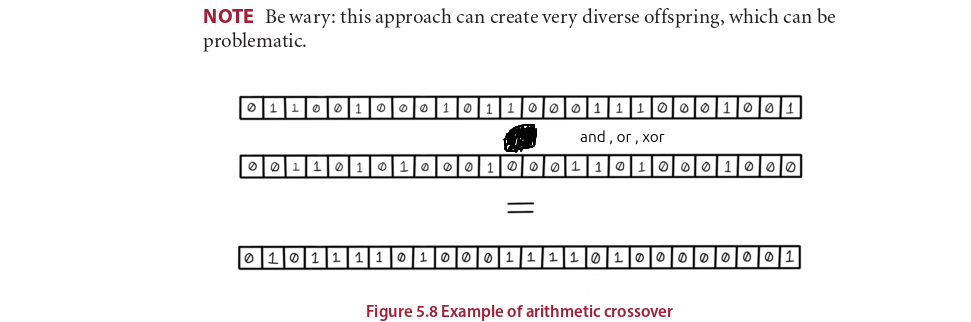

# 3.2-Boundary mutation
In boundary mutation, a gene randomly selected from a real-value encoded chromo-
some is set randomly to a lower bound value or upper bound value
 

the original value happens to be 0 and will be adjusted 
to 6, which is the maximum for that item

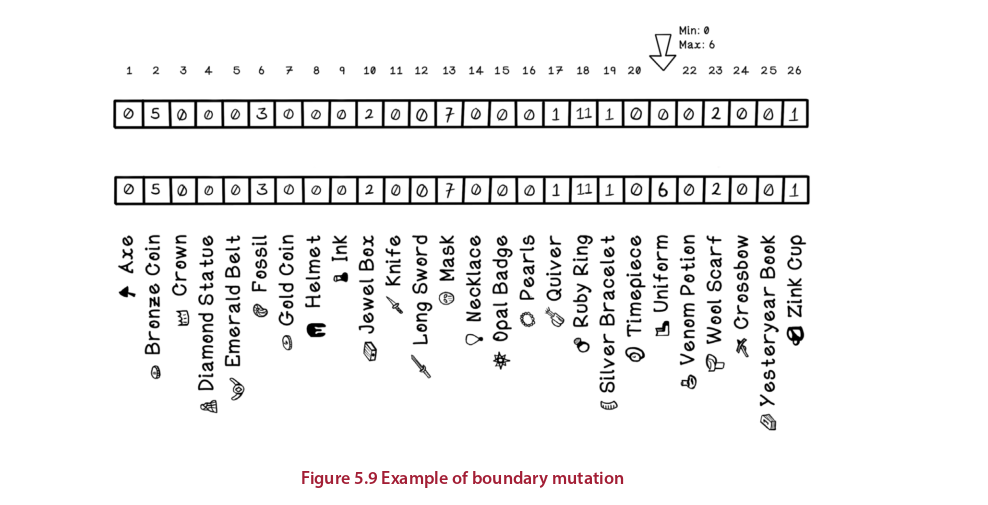



`Why Boundary Mutation Works `

Boundary mutation is incredibly effective because it forces your algorithm to test the absolute extremes of your search space.

1- Testing the Best Items: If an item like the 'Crown' is super valuable and lightweight, the optimal answer is usually to take the maximum allowed (the upper bound). Boundary mutation instantly maxes it out to see if the score skyrockets.   

2- Dropping the Worst Items: If an item is heavy and worthless, the optimal answer is to take zero of it (the lower bound).  

In [207]:
import random

def boundary_mutation(children, mutation_rate):
    """
    Mutates children by forcing a random gene to its absolute minimum (0) 
    or absolute maximum (the item's quantity limit).
    """
    mutation_chance = mutation_rate / 100.0
    
    for child in children:
        # Roll the dice to see if this child gets mutated
        if random.random() < mutation_chance:
            
            chromosome = child[INDIVIDUAL_CHROMOSOME_INDEX]
            
            # 1. Pick a random gene (item) to mutate
            random_index = random.randint(0, len(chromosome) - 1)
            
            # 2. Find the boundaries for this specific item
            lower_bound = 0
            upper_bound = knapsack_items[random_index][KNAPSACK_ITEM_QUANTITY_INDEX]
            
            # 3. Randomly snap to either the absolute minimum or absolute maximum
            # A 50/50 chance to pick either the lower or upper bound
            if random.random() < 0.5:
                chromosome[random_index] = lower_bound
            else:
                chromosome[random_index] = upper_bound
                
    return children

### 3.3 -Arithmetic mutation
In arithmetic mutation, a randomly selected gene in a real-value-encoded chromosome 
is changed by adding or subtracting a small number


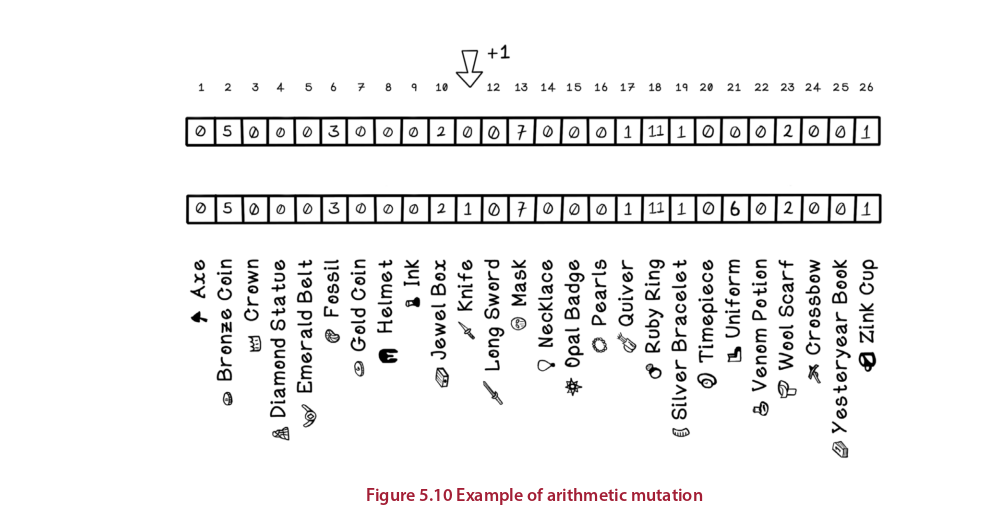

In [208]:
import random

def arithmetic_mutation(children, mutation_rate):
    """
    Mutates children by picking a random gene and nudging its integer value
    up by 1 or down by 1, while staying strictly within the allowed item limits.
    """
    mutation_chance = mutation_rate / 100.0
    
    for child in children:
        # Roll the dice to see if this child mutates
        if random.random() < mutation_chance:
            
            chromosome = child[INDIVIDUAL_CHROMOSOME_INDEX]
            
            # 1. Pick a random gene (item) to mutate
            random_index = random.randint(0, len(chromosome) - 1)
            
            # 2. Find the upper boundary for this specific item
            upper_bound = knapsack_items[random_index][KNAPSACK_ITEM_QUANTITY_INDEX]
            
            # 3. Decide to either add 1 or subtract 1 (50/50 chance)
            if random.random() < 0.5:
                chromosome[random_index] += 1
            else:
                chromosome[random_index] -= 1
                
            # 4. Clamping: Prevent the number from breaking the rules
            if chromosome[random_index] < 0:
                chromosome[random_index] = 0
            elif chromosome[random_index] > upper_bound:
                chromosome[random_index] = upper_bound
                
    return children

# Run experiment

In [ ]:
# Set the hyper parameters for the genetic algorithm
NUMBER_OF_ITERATIONS=5
NUMBER_OF_GENERATIONS=1000
INITIAL_POPULATION_SIZE = 5000
MUTATION_RATE = 10
KNAPSACK_WEIGHT_CAPACITY = 6404180


def run_ga():
    best_global_fitness = 0
    # 1. Initialize
    global_population = generate_initial_population(INITIAL_POPULATION_SIZE)

    for generation in range(NUMBER_OF_GENERATIONS):
        # 2. Evaluate current population and track the best
        current_best = calculate_population_fitness(global_population, KNAPSACK_WEIGHT_CAPACITY)
        if current_best > best_global_fitness:
            best_global_fitness = current_best

        # 3. Select Parents (Tournament Selection)
        # We need 990 children to replace everyone except the 10 Elites
        the_chosen_parents = select_parents(global_population, INITIAL_POPULATION_SIZE - 10, tournament_size=3)

        # 4. Crossover (Arithmetic Crossover)
        the_children = arithmetic_crossover(the_chosen_parents)

        # 5. Mutation (Boundary Mutation)
        the_children = boundary_mutation(the_children, MUTATION_RATE) # You can switch to arithmetic_mutation if you want a different mutation style

        # 6. Evaluate the new children BEFORE merging (Crucial Step!)
        calculate_population_fitness(the_children, KNAPSACK_WEIGHT_CAPACITY)

        # 7. Merge (Generational with Elitism)
        global_population = merge_generational_elitism(global_population, the_children, elite_count=10)

    # Do one final check at the very end just to ensure the absolute best is recorded
    final_best = calculate_population_fitness(global_population, KNAPSACK_WEIGHT_CAPACITY)
    if final_best > best_global_fitness:
        best_global_fitness = final_best
        
    print('=========================================')
    print('INTEGER KNAPSACK RESULTS:')
    print('Best fitness found: ', best_global_fitness)
    print('Final population size: ', len(global_population))
    print('=========================================')

# Run the algorithm!
# Run the genetic algorithm for a number of iterations
for i in range(0, NUMBER_OF_ITERATIONS):
    run_ga()



# 4-Order encoding: Working with sequences   
# 5-Tree encoding: Working with hierarchies

self study

# Reference  



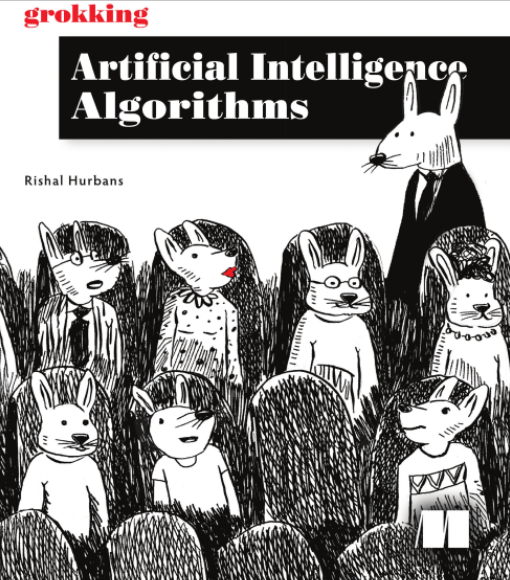